# Linum BaSiC — Comprehensive Usage Example

This notebook demonstrates the full workflow for correcting spatially non-uniform
illumination (shading) using the **Linum BaSiC** package — the algorithm is designed
for fluorescence and bright-field microscopy, but works on any image stack that
shares a common illumination profile.

The bundled sample image is a greyscale Landsat satellite scene (NASA/USGS),
used here as a convenient spatial-texture stand-in.  See Section 2 for details.

**What you will learn:**
- How to load the bundled sample image and build a synthetic degraded stack
- How to configure and run the BaSiC algorithm
- How to inspect the estimated flat-field and dark-field profiles
- How to apply the correction and evaluate the quality improvement quantitatively

**Reference:** Peng T. *et al.*, "A BaSiC tool for background and shading correction
of optical microscopy images," *Nat. Commun.* **8**, 14836 (2017).
[DOI:10.1038/ncomms14836](https://doi.org/10.1038/ncomms14836)

## 1. Import Required Libraries

Core scientific stack (`numpy`, `matplotlib`) plus the `linum_basic` package itself.
`sbh_simulator` is imported later in Step 3 where it is first used.

In [1]:
%matplotlib inline

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

import linum_basic
from linum_basic import BaSiC
from linum_basic.data import load_sample_image

# Crisp figures for the docs site
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 150,
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

print(f"linum-basic version : {linum_basic.__version__}")
print(f"numpy version       : {np.__version__}")

linum-basic version : 0.2.0
numpy version       : 2.4.6


## 2. Load the Sample Image

`linum_basic.data.load_sample_image()` returns a greyscale image bundled with
the package via `importlib.resources` — no external download required.

> **Note — sample image provenance:** The bundled image is a Landsat satellite
> scene provided by NASA/USGS and is used here *purely as a convenient
> greyscale test image* with realistic spatial structure.  Real BaSiC workflows
> operate on stacks of microscopy field-of-view acquisitions (e.g. widefield
> fluorescence, bright-field, or spinning-disk tiles from the same slide
> position).  The algorithm is agnostic to the image content; the only
> requirement is that all frames share the same illumination profile.

We tile the single image into non-overlapping 128 × 128 patches to simulate
such a multi-frame stack.  In a real workflow you would pass a directory of
per-field acquisitions to the `BaSiC` constructor instead.

In [2]:
TILE = 128  # patch size used throughout the notebook

# Load bundled greyscale image (uint8, shape H x W)
source = load_sample_image()
print(f"Source image  shape : {source.shape}")
print(f"              dtype : {source.dtype}")
print(f"              range : [{source.min()}, {source.max()}]")

# Tile into non-overlapping TILE x TILE patches ─────────────────────────────
h, w = source.shape
nh, nw = h // TILE, w // TILE
# Crop to an exact multiple of TILE, normalise to float32 [0, 1]
cropped = source[: nh * TILE, : nw * TILE].astype(np.float32) / 255.0
# Reshape → (N, TILE, TILE)
stack = cropped.reshape(nh, TILE, nw, TILE).transpose(0, 2, 1, 3).reshape(nh * nw, TILE, TILE)

print(f"\nTiled stack   shape : {stack.shape}  ({stack.shape[0]} patches)")
print(f"              dtype : {stack.dtype}")
print(f"              range : [{stack.min():.3f}, {stack.max():.3f}]")

Source image  shape : (1442, 2048)
              dtype : uint8
              range : [0, 255]

Tiled stack   shape : (176, 128, 128)  (176 patches)
              dtype : float32
              range : [0.000, 1.000]


## 3. Synthesise a Shading-Corrupted Stack

Real fluorescence microscopes exhibit a smooth, spatially-varying sensitivity
profile — the *flat-field* — typically brightest at the optical axis and
dimmer towards the edges (vignetting).  There may also be a spatially-varying
*dark-field* offset caused by camera read-out noise and auto-fluorescence.

We use [sbh-simulator](https://github.com/linum-uqam/sbh_simulator)'s
`generate_gaussian_vignette` to produce a realistic synthetic flat-field, and
construct a simple radial dark-field on top of it.  Using the simulator as the
single source of truth ensures the notebook and the integration test suite use
identical vignette generation logic.

| Component | Model | Intensity range |
|-----------|-------|-----------------|
| Flat-field (vignette) | Gaussian (sbh-simulator, σ ≈ 0.7, seed 42) | 0 – 1, mean ≈ 1 after normalisation |
| Dark-field | Radially-increasing offset | 0 – 0.05 |

Corrupted stack statistics
  shape : (176, 128, 128)
  mean  : 0.2664
  std   : 0.2122


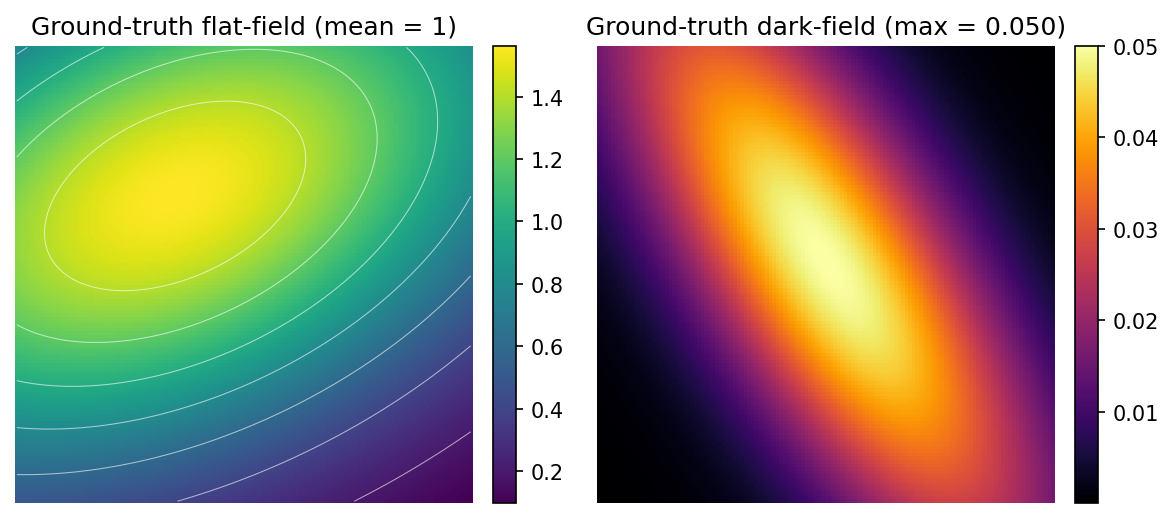

In [3]:
import random

from sbh_simulator.simulator import generate_gaussian_darkfield, generate_gaussian_vignette

_rng = random.Random(42)
rng = np.random.default_rng(42)

# ── Ground-truth flat-field: Gaussian vignette from sbh-simulator ────────────
gt_flatfield = generate_gaussian_vignette(width=TILE, height=TILE, sigma=0.7, rng=_rng).astype(np.float32)
gt_flatfield /= gt_flatfield.mean()  # normalise so mean == 1

# ── Ground-truth dark-field: Gaussian bump from sbh-simulator ────────────────
gt_darkfield = generate_gaussian_darkfield(width=TILE, height=TILE, sigma=0.7, max_offset=0.05, rng=_rng).astype(np.float32)

# ── Apply degradation: corrupted = clean * flatfield + darkfield + noise ──────
noise_std = 0.005
corrupted = stack * gt_flatfield[np.newaxis] + gt_darkfield[np.newaxis]
corrupted += rng.normal(0, noise_std, corrupted.shape).astype(np.float32)
corrupted = np.clip(corrupted, 0, 1)

print("Corrupted stack statistics")
print(f"  shape : {corrupted.shape}")
print(f"  mean  : {corrupted.mean():.4f}")
print(f"  std   : {corrupted.std():.4f}")

# ── Visualise ground-truth components ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
im0 = axes[0].imshow(gt_flatfield, cmap="viridis")
axes[0].contour(gt_flatfield, levels=8, colors="w", linewidths=0.5, alpha=0.6)
axes[0].set_title("Ground-truth flat-field (mean = 1)")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(gt_darkfield, cmap="inferno")
axes[1].set_title(f"Ground-truth dark-field (max = {gt_darkfield.max():.3f})")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

## 4. Visualise the Raw (Corrupted) Image Stack

The montage below shows the first 12 patches.  The shading gradient is clearly
visible: patches are brighter at their centres and progressively dimmer towards
the corners.  The mean-intensity image on the right makes the vignette structure
even more apparent.

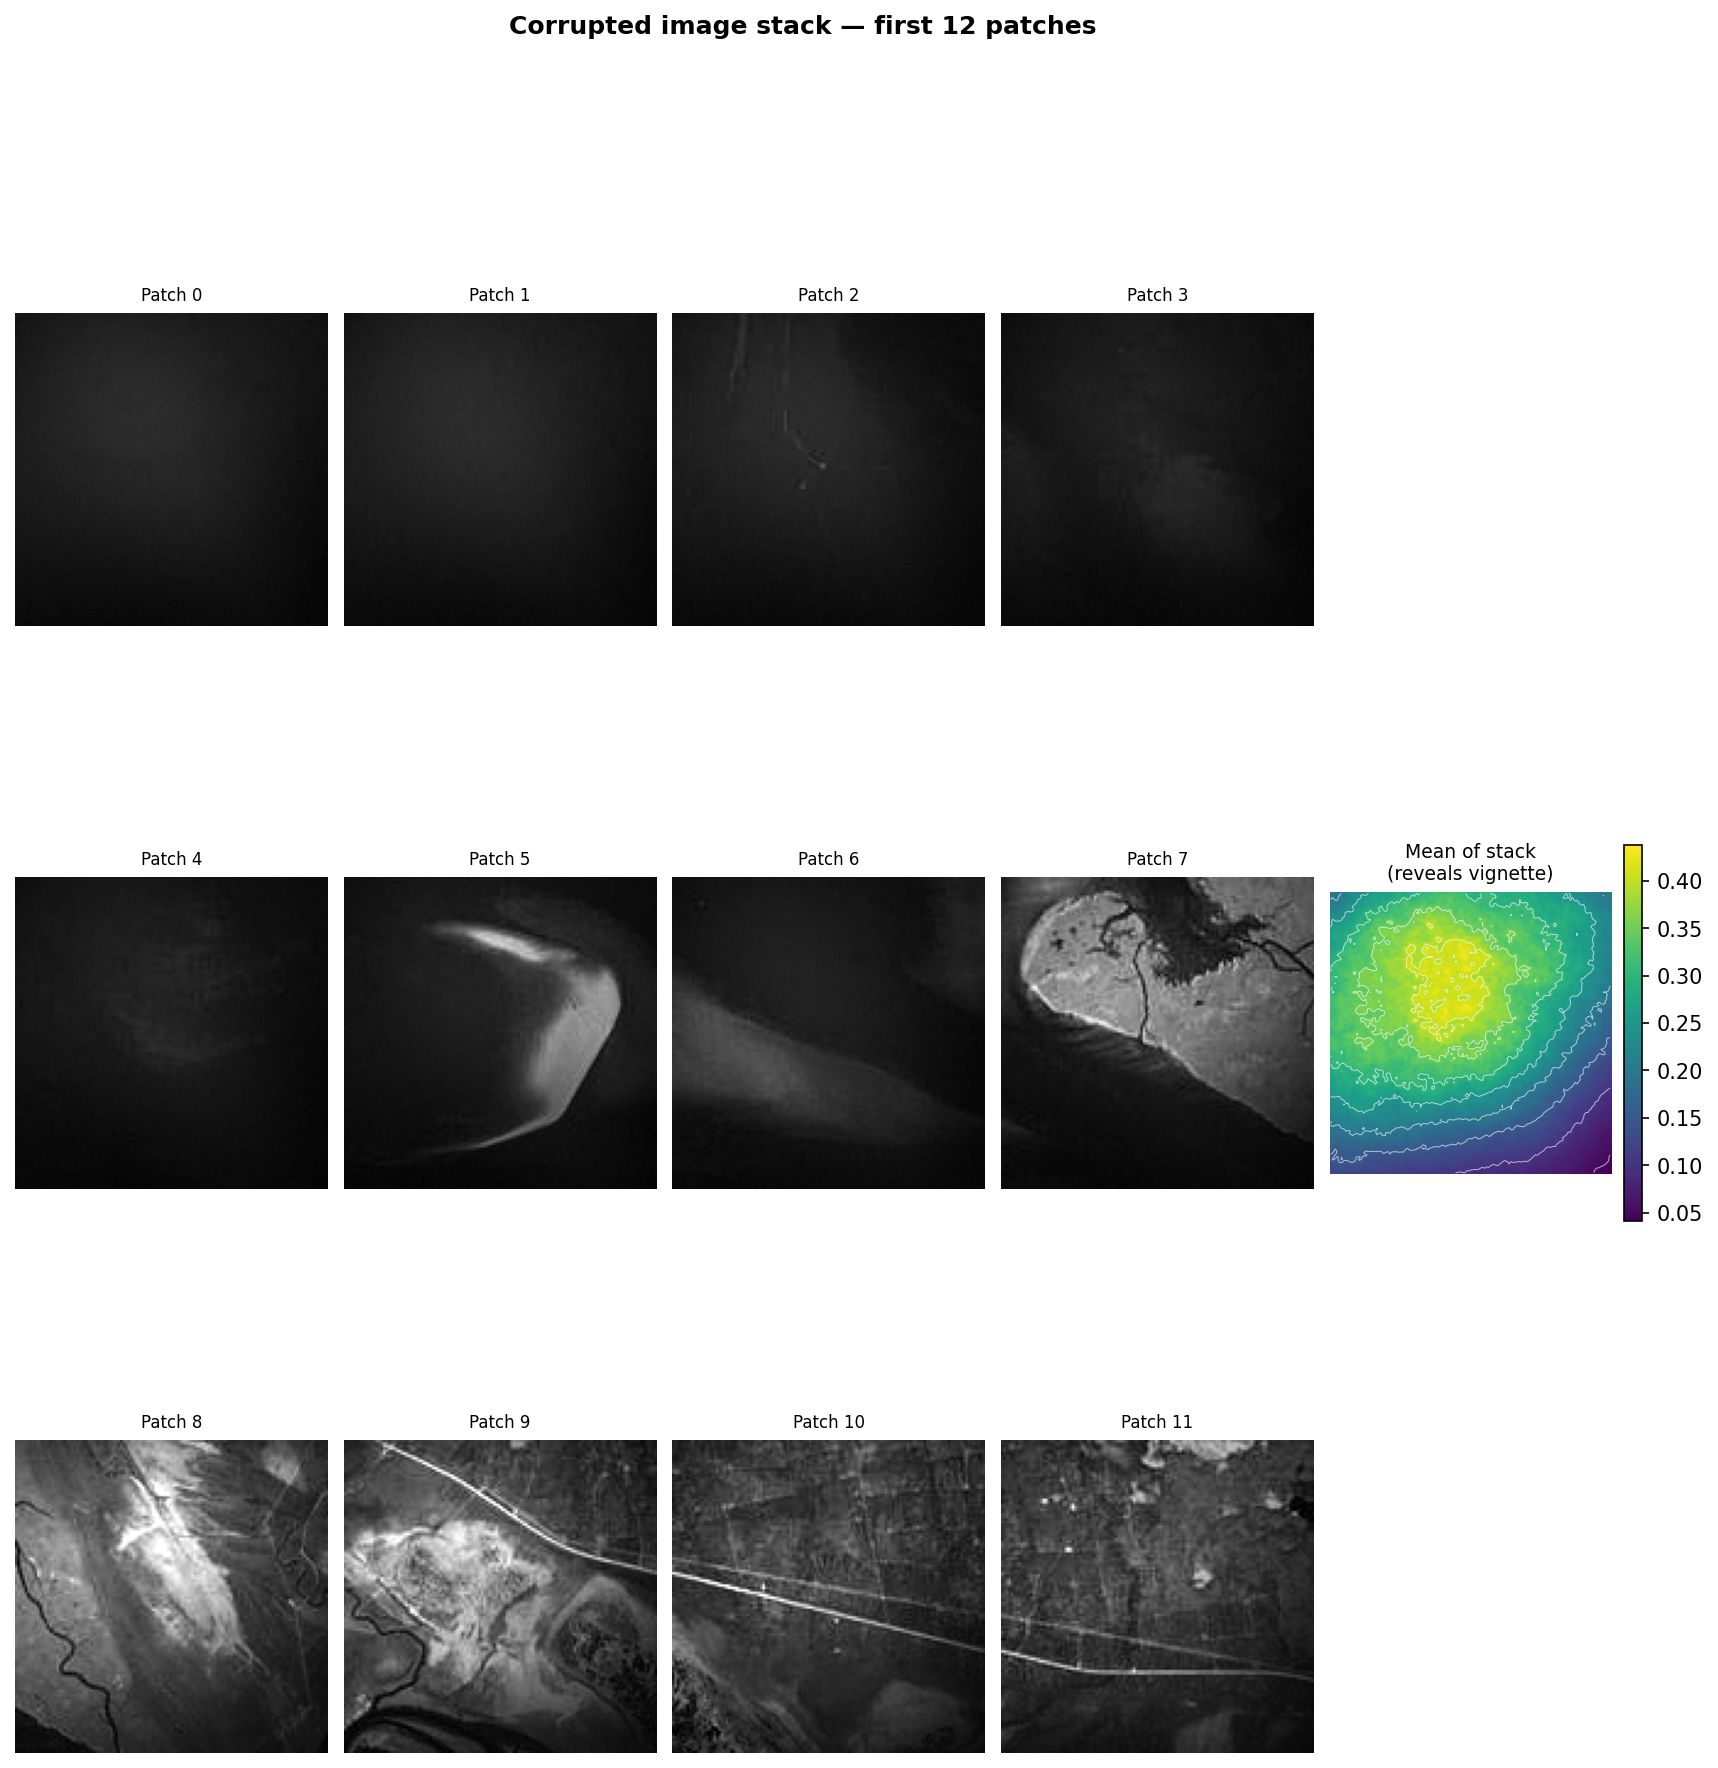

In [4]:
n_show = min(12, len(corrupted))
ncols = 4
nrows = (n_show + ncols - 1) // ncols

fig = plt.figure(figsize=(14, 3.5 * nrows + 3.5))
gs = gridspec.GridSpec(nrows, ncols + 1, figure=fig, wspace=0.05, hspace=0.15)

vmin, vmax = corrupted[:n_show].min(), corrupted[:n_show].max()
for i in range(n_show):
    ax = fig.add_subplot(gs[i // ncols, i % ncols])
    ax.imshow(corrupted[i], cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"Patch {i}", fontsize=8)
    ax.axis("off")

ax_mean = fig.add_subplot(gs[:, ncols])
im = ax_mean.imshow(corrupted.mean(axis=0), cmap="viridis")
ax_mean.contour(corrupted.mean(axis=0), levels=8, colors="w", linewidths=0.5, alpha=0.6)
ax_mean.set_title("Mean of stack\n(reveals vignette)", fontsize=9)
ax_mean.axis("off")
fig.colorbar(im, ax=ax_mean, fraction=0.06, pad=0.04)

fig.suptitle("Corrupted image stack — first 12 patches", fontsize=12, fontweight="bold")
plt.show()

## 5. Configure and Run BaSiC

The `BaSiC` class exposes several tuning knobs.  The most important ones to
understand are:

| Parameter | Default | Effect |
|-----------|---------|--------|
| `estimate_darkfield` | `False` | Enable joint dark-field estimation |
| `working_size` | `128` | Internal resolution for optimisation.  Increase to `256` for finer flat-field detail at the cost of compute time |
| `l_s` | `None` (auto) | Flat-field regularisation weight λ_s.  Auto-tuned from DCT of mean image as `dct_sum / 800`.  Increase to enforce a smoother flat-field |
| `l_d` | `None` (auto) | Dark-field regularisation weight λ_d.  Auto-tuned as `dct_sum / 2000` |
| `epsilon` | `0.1` | Stability constant ε in the reweighted-L1 update.  Smaller → sharper weight contrast |
| `max_reweighting_iterations` | `10` | Hard cap on outer reweighting loop |
| `reweighting_tolerance` | `1e-3` | Convergence threshold (relative change in flat-field and dark-field) |

`prepare()` loads images and auto-tunes the regularisation parameters.
`run()` iterates the reweighted ALM loop until convergence.

> **Tip:** You can override `l_s` / `l_d` *after* calling `prepare()` and
> before calling `run()` if the auto-tuned values produce an overly smooth or
> overly rough flat-field.

In [5]:
# Instantiate BaSiC with dark-field estimation enabled.
# verbose=True enables tqdm progress bars — useful when running interactively.
# Disabled here so the docs page stays clean; flip it when running locally.
model = BaSiC(corrupted, estimate_darkfield=True, verbose=False)

# (Optional) Override working resolution — 128 is sufficient for this demo
model.working_size = 128

# prepare(): load the stack and auto-tune l_s / l_d
model.prepare()
print(f"Auto-tuned  l_s = {model.l_s:.4f}")
print(f"Auto-tuned  l_d = {model.l_d:.4f}")

# run(): reweighted ALM optimisation loop
model.run()
print(f"Converged after {model.reweighting_iteration} reweighting iteration(s)")

Auto-tuned  l_s = 0.6449
Auto-tuned  l_d = 0.2580
Converged after 10 reweighting iteration(s)


## 6. Inspect the Estimated Flat-Field and Dark-Field

`get_flatfield()` and `get_darkfield()` return copies of the full-resolution
profiles estimated by BaSiC.  A well-estimated flat-field should:

- Be smooth and bell-shaped (Gaussian-like for a Gaussian illumination profile)
- Have a mean value close to 1.0 (BaSiC normalises to mean = 1)
- Closely match the ground-truth vignette we applied in Step 3

A well-estimated dark-field should:
- Be smooth and small in magnitude (typically a few percent of signal)
- Capture the radially-increasing offset structure we applied

Flat-field  shape : (128, 128)  mean = 1.0000
Dark-field  shape : (128, 128)  mean = -0.0000


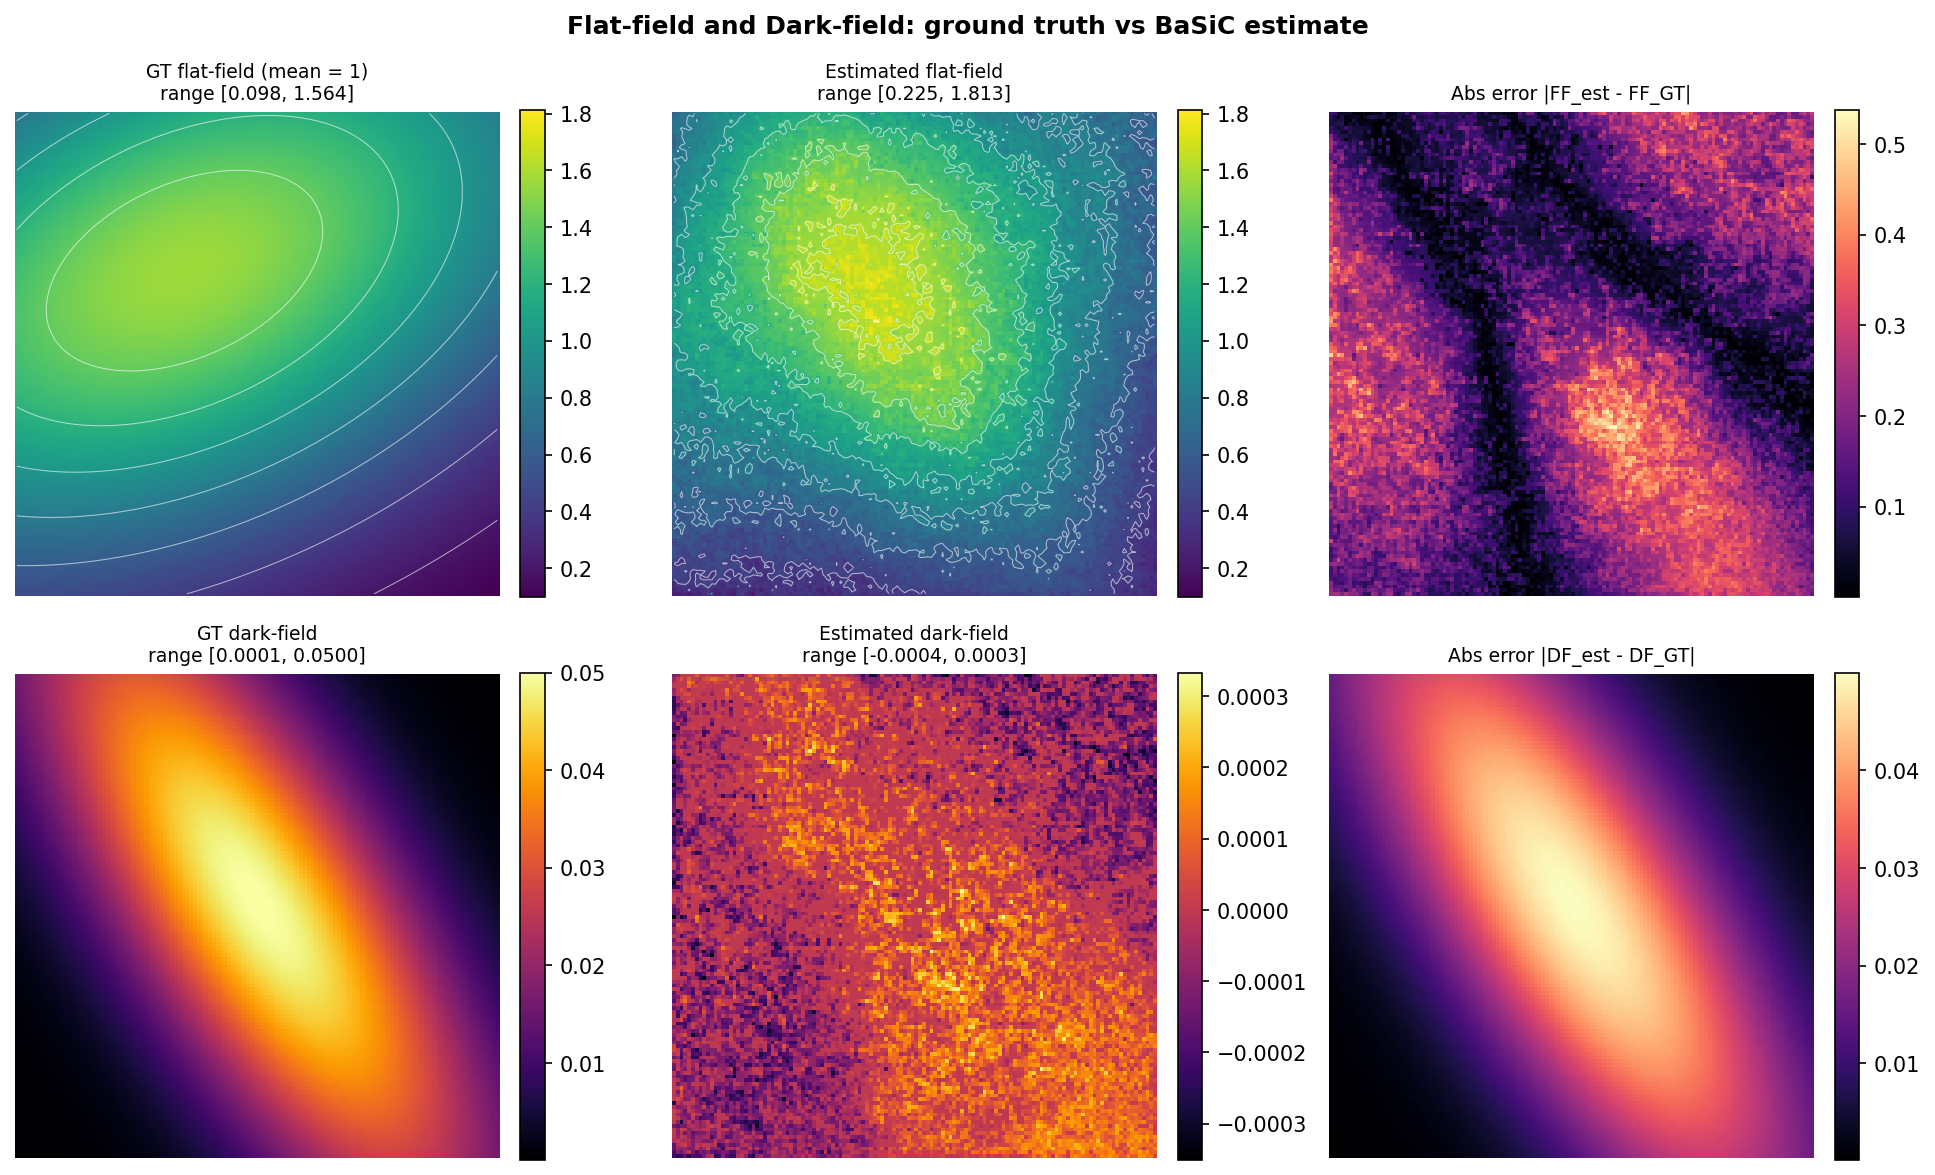


Pearson r (flat-field) : 0.8522  (1.0 = perfect)
Pearson r (dark-field) : 0.5966  (1.0 = perfect)


In [6]:
flatfield = model.get_flatfield()
darkfield = model.get_darkfield()

print(f"Flat-field  shape : {flatfield.shape}  mean = {flatfield.mean():.4f}")
print(f"Dark-field  shape : {darkfield.shape}  mean = {darkfield.mean():.4f}")

# Normalise ground truth to mean = 1 for a fair comparison
gt_ff_norm = gt_flatfield / gt_flatfield.mean()

# Shared colour scale so GT and estimate are directly comparable
ff_vmin = min(gt_ff_norm.min(), flatfield.min())
ff_vmax = max(gt_ff_norm.max(), flatfield.max())

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle("Flat-field and Dark-field: ground truth vs BaSiC estimate", fontsize=12, fontweight="bold")

panels = [
    (
        axes[0, 0],
        gt_ff_norm,
        "viridis",
        True,
        f"GT flat-field (mean = 1)\nrange [{gt_ff_norm.min():.3f}, {gt_ff_norm.max():.3f}]",
        ff_vmin,
        ff_vmax,
    ),
    (
        axes[0, 1],
        flatfield,
        "viridis",
        True,
        f"Estimated flat-field\nrange [{flatfield.min():.3f}, {flatfield.max():.3f}]",
        ff_vmin,
        ff_vmax,
    ),
    (axes[0, 2], np.abs(flatfield - gt_ff_norm), "magma", False, "Abs error |FF_est - FF_GT|", None, None),
    (
        axes[1, 0],
        gt_darkfield,
        "inferno",
        False,
        f"GT dark-field\nrange [{gt_darkfield.min():.4f}, {gt_darkfield.max():.4f}]",
        None,
        None,
    ),
    (
        axes[1, 1],
        darkfield,
        "inferno",
        False,
        f"Estimated dark-field\nrange [{darkfield.min():.4f}, {darkfield.max():.4f}]",
        None,
        None,
    ),
    (axes[1, 2], np.abs(darkfield - gt_darkfield), "magma", False, "Abs error |DF_est - DF_GT|", None, None),
]

for ax, data, cmap, contours, title, vmin, vmax in panels:
    kw = {"vmin": vmin, "vmax": vmax} if vmin is not None else {}
    im = ax.imshow(data, cmap=cmap, interpolation="nearest", **kw)
    if contours:
        ax.contour(data, levels=8, colors="w", linewidths=0.5, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

# Pearson correlation as a summary metric
pearson_ff = float(np.corrcoef(flatfield.ravel(), gt_ff_norm.ravel())[0, 1])
pearson_df = float(np.corrcoef(darkfield.ravel(), gt_darkfield.ravel())[0, 1])
print(f"\nPearson r (flat-field) : {pearson_ff:.4f}  (1.0 = perfect)")
print(f"Pearson r (dark-field) : {pearson_df:.4f}  (1.0 = perfect)")

## 7. Apply the Correction

`model.normalize(image)` applies the BaSiC correction to a single image:

$$I_\text{corrected} = \frac{I - \text{darkfield}}{\text{flatfield} + \varepsilon}$$

where ε is a small stabilising constant.

We apply this to every patch and reassemble the full corrected image mosaic for
a side-by-side comparison.

Corrected stack  shape : (176, 128, 128)
                 range : [0.000, 1.000]


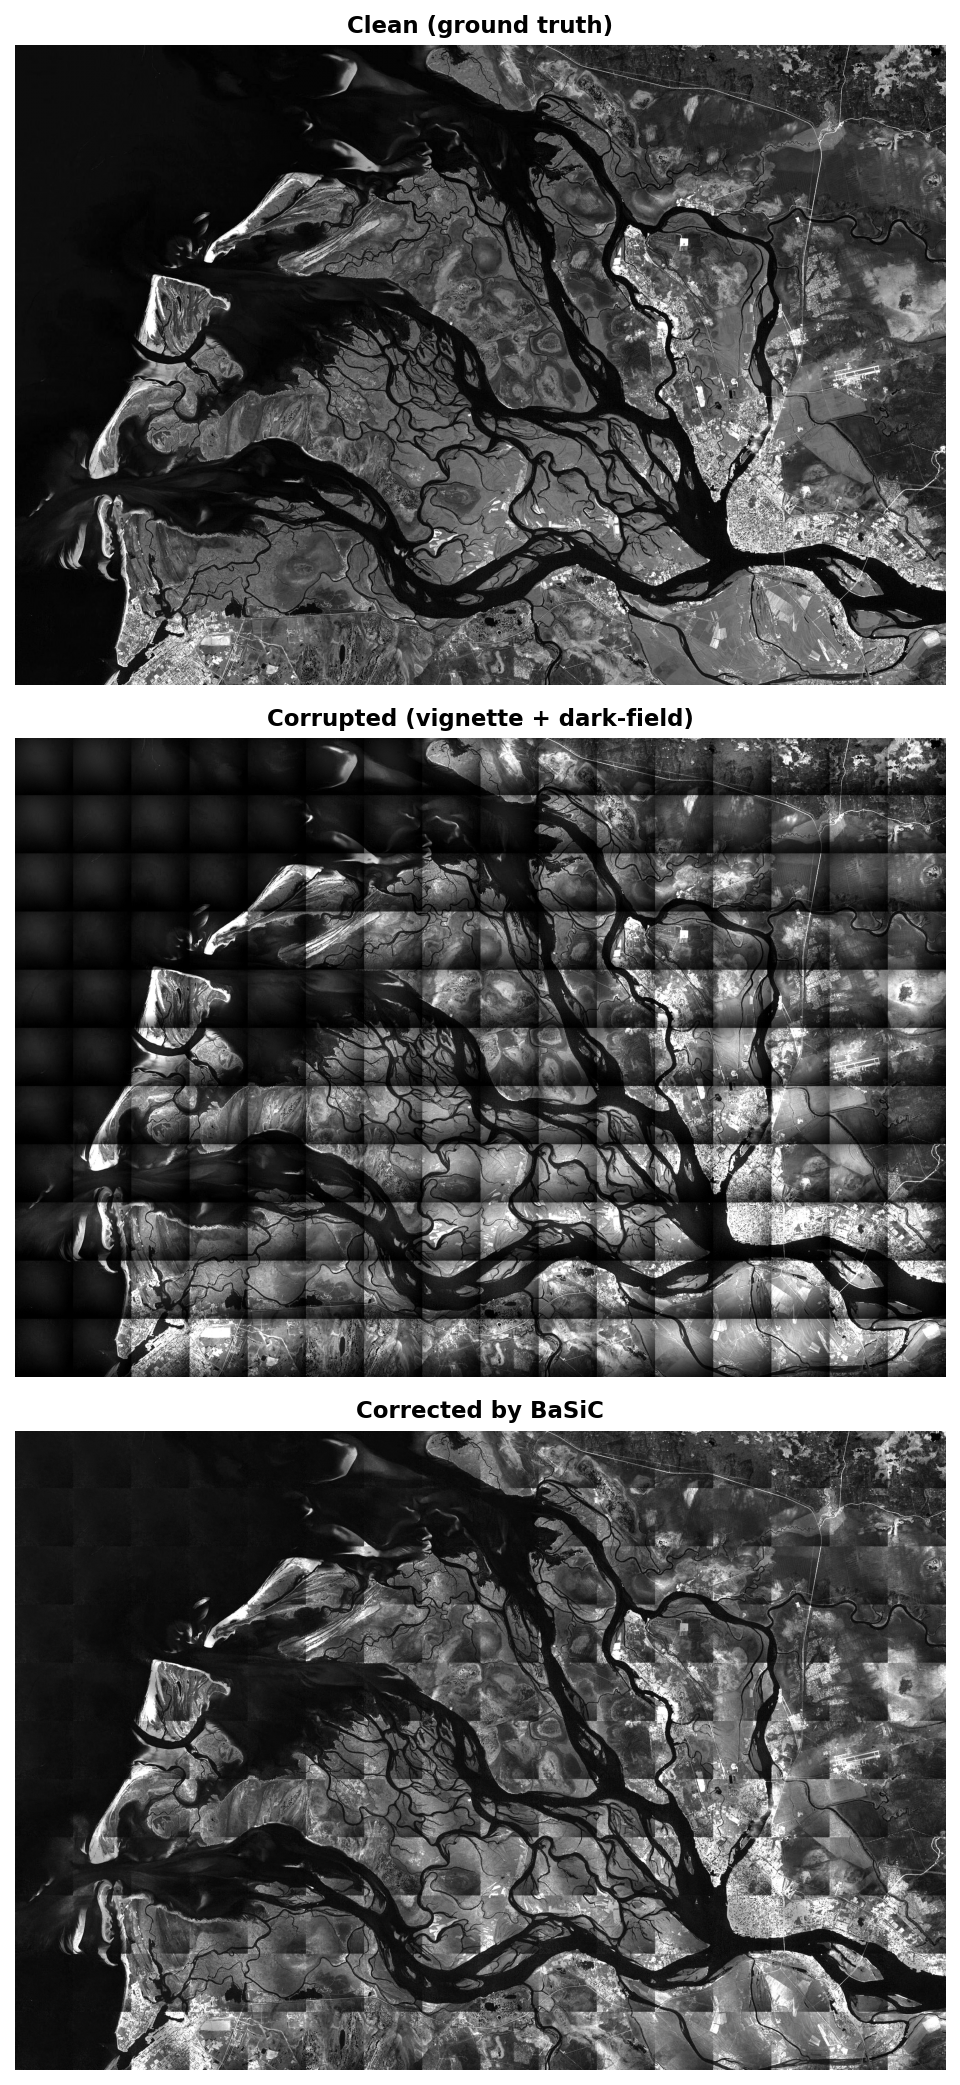

In [7]:
# Correct every patch in the stack
corrected = np.stack([model.normalize(corrupted[i]) for i in range(len(corrupted))])
corrected = np.clip(corrected, 0, 1)

print(f"Corrected stack  shape : {corrected.shape}")
print(f"                 range : [{corrected.min():.3f}, {corrected.max():.3f}]")


# ── Reassemble into full mosaic for visual comparison ─────────────────────────
def make_mosaic(stack: np.ndarray, nh: int, nw: int, tile: int) -> np.ndarray:
    """Reassemble (nh*nw, tile, tile) stack into (nh*tile, nw*tile) image."""
    return stack.reshape(nh, nw, tile, tile).transpose(0, 2, 1, 3).reshape(nh * tile, nw * tile)


mosaic_source = make_mosaic(stack, nh, nw, TILE)
mosaic_corrupt = make_mosaic(corrupted, nh, nw, TILE)
mosaic_correct = make_mosaic(corrected, nh, nw, TILE)

# Shared intensity limits
vmin_g = float(np.percentile(mosaic_corrupt, 2))
vmax_g = float(np.percentile(mosaic_corrupt, 98))

# Stack vertically so each panel is legible at the docs page width
fig, axes = plt.subplots(3, 1, figsize=(8, 14))
titles = ["Clean (ground truth)", "Corrupted (vignette + dark-field)", "Corrected by BaSiC"]
mosaics = [mosaic_source, mosaic_corrupt, mosaic_correct]

for ax, title, mosaic in zip(axes, titles, mosaics, strict=True):
    ax.imshow(mosaic, cmap="gray", vmin=vmin_g, vmax=vmax_g)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")

fig.tight_layout()
plt.show()

## 8. Pixel-Profile Line Scans

A horizontal line scan through the centre of an individual patch makes the
illumination gradient immediately visible.  The corrected profile should be
much closer to the clean (ground-truth) profile.

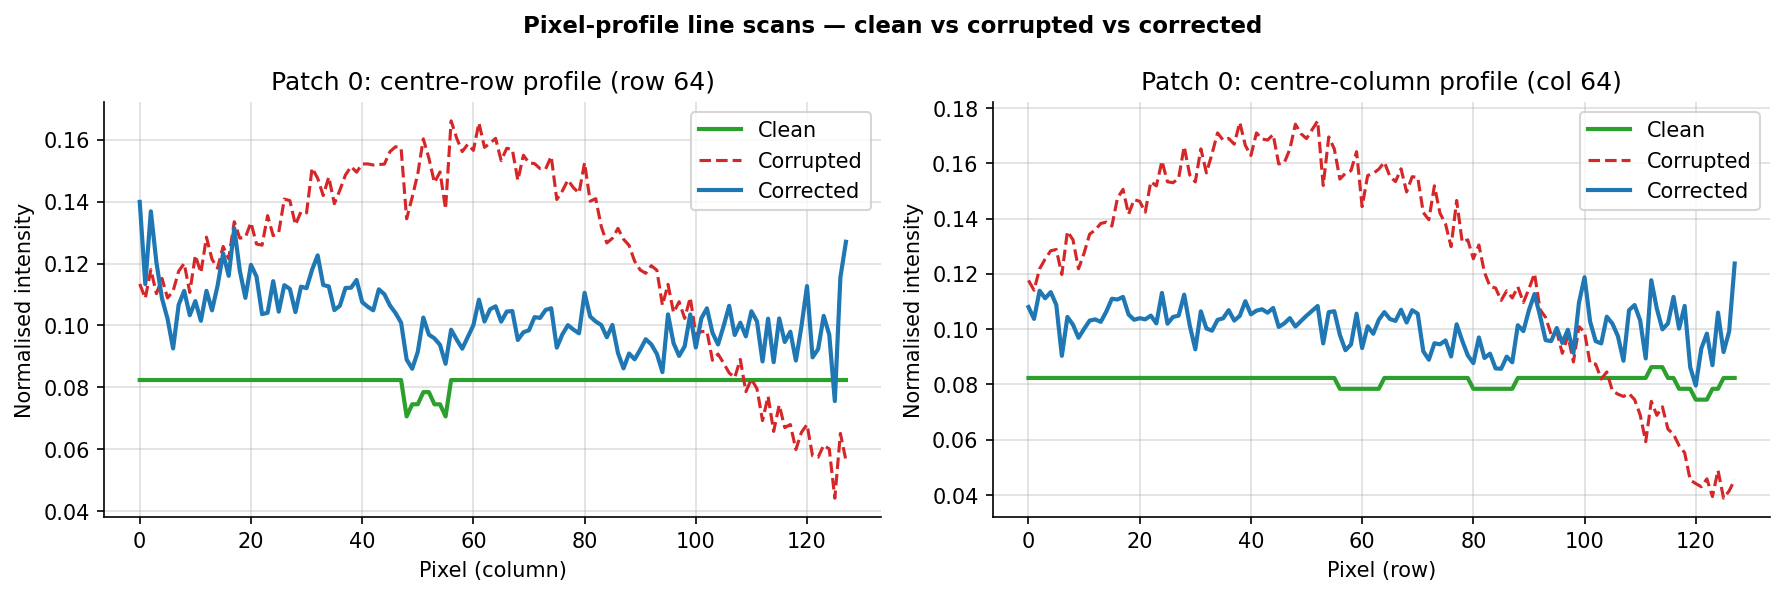

In [8]:
patch_idx = 0  # pick any patch index
row = TILE // 2  # central horizontal line

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: centre-row line scan
axes[0].plot(stack[patch_idx, row, :], color="tab:green", linewidth=2, label="Clean")
axes[0].plot(corrupted[patch_idx, row, :], color="tab:red", linewidth=1.5, linestyle="--", label="Corrupted")
axes[0].plot(corrected[patch_idx, row, :], color="tab:blue", linewidth=2, label="Corrected")
axes[0].set_xlabel("Pixel (column)")
axes[0].set_ylabel("Normalised intensity")
axes[0].set_title(f"Patch {patch_idx}: centre-row profile (row {row})")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Right panel: centre-column line scan
col = TILE // 2
axes[1].plot(stack[patch_idx, :, col], color="tab:green", linewidth=2, label="Clean")
axes[1].plot(corrupted[patch_idx, :, col], color="tab:red", linewidth=1.5, linestyle="--", label="Corrupted")
axes[1].plot(corrected[patch_idx, :, col], color="tab:blue", linewidth=2, label="Corrected")
axes[1].set_xlabel("Pixel (row)")
axes[1].set_ylabel("Normalised intensity")
axes[1].set_title(f"Patch {patch_idx}: centre-column profile (col {col})")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

fig.suptitle("Pixel-profile line scans — clean vs corrupted vs corrected", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

## 9. Quantitative Quality Metrics

The **Coefficient of Variation (CV)** measures the relative spread of pixel
intensities within each patch:

$$\text{CV} = \frac{\sigma}{\mu}$$

A low CV indicates uniform illumination.  BaSiC should substantially reduce the
mean CV across the stack.

We also compute the **Pearson correlation coefficient** between the corrected
and ground-truth-clean images as a measure of signal recovery.

Coefficient of Variation summary
  Clean      mean CV : 0.5103
  Corrupted  mean CV : 0.5976  (+17.1% vs clean)
  Corrected  mean CV : 0.5042  (-15.6% vs corrupted)

  CV reduction after BaSiC: 15.6%


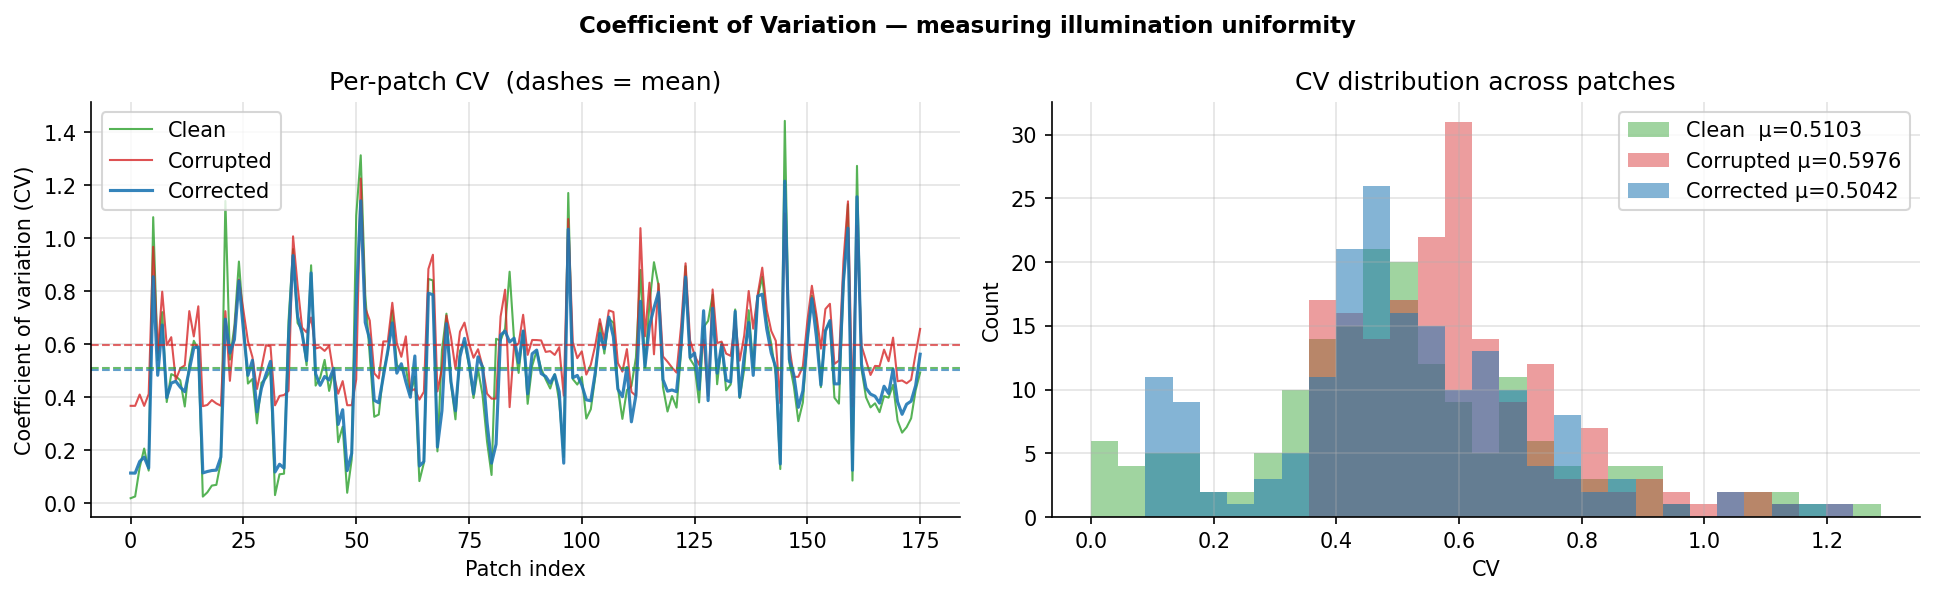


Pearson r (corrupted vs clean)  : 0.8300
Pearson r (corrected vs clean)  : 0.9278


In [9]:
eps = 1e-9
cv_clean = stack.std(axis=(1, 2)) / (stack.mean(axis=(1, 2)) + eps)
cv_corrupted = corrupted.std(axis=(1, 2)) / (corrupted.mean(axis=(1, 2)) + eps)
cv_corrected = corrected.std(axis=(1, 2)) / (corrected.mean(axis=(1, 2)) + eps)

# ── Summary table ─────────────────────────────────────────────────────────────
print("Coefficient of Variation summary")
print(f"  Clean      mean CV : {cv_clean.mean():.4f}")
pct_vs_clean = 100 * (cv_corrupted.mean() / cv_clean.mean() - 1)
pct_vs_corrupt = 100 * (cv_corrected.mean() / cv_corrupted.mean() - 1)
print(f"  Corrupted  mean CV : {cv_corrupted.mean():.4f}  (+{pct_vs_clean:.1f}% vs clean)")
print(f"  Corrected  mean CV : {cv_corrected.mean():.4f}  ({pct_vs_corrupt:.1f}% vs corrupted)")

cv_reduction_pct = 100 * (1 - cv_corrected.mean() / cv_corrupted.mean())
print(f"\n  CV reduction after BaSiC: {cv_reduction_pct:.1f}%")

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: per-patch CV line chart
x = np.arange(len(stack))
axes[0].plot(x, cv_clean, color="tab:green", alpha=0.8, linewidth=1, label="Clean")
axes[0].plot(x, cv_corrupted, color="tab:red", alpha=0.8, linewidth=1, label="Corrupted")
axes[0].plot(x, cv_corrected, color="tab:blue", alpha=0.9, linewidth=1.5, label="Corrected")
axes[0].axhline(cv_clean.mean(), color="tab:green", linestyle="--", linewidth=1, alpha=0.7)
axes[0].axhline(cv_corrupted.mean(), color="tab:red", linestyle="--", linewidth=1, alpha=0.7)
axes[0].axhline(cv_corrected.mean(), color="tab:blue", linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_xlabel("Patch index")
axes[0].set_ylabel("Coefficient of variation (CV)")
axes[0].set_title("Per-patch CV  (dashes = mean)")
axes[0].legend()
axes[0].grid(True, alpha=0.35)

# Right: CV histogram / KDE-style overlapping bars
bins = np.linspace(0, max(cv_corrupted.max(), cv_corrected.max()) * 1.05, 30)
axes[1].hist(cv_clean, bins=bins, alpha=0.45, color="tab:green", label=f"Clean  μ={cv_clean.mean():.4f}")
axes[1].hist(cv_corrupted, bins=bins, alpha=0.45, color="tab:red", label=f"Corrupted μ={cv_corrupted.mean():.4f}")
axes[1].hist(cv_corrected, bins=bins, alpha=0.55, color="tab:blue", label=f"Corrected μ={cv_corrected.mean():.4f}")
axes[1].set_xlabel("CV")
axes[1].set_ylabel("Count")
axes[1].set_title("CV distribution across patches")
axes[1].legend()
axes[1].grid(True, alpha=0.35)

fig.suptitle(
    "Coefficient of Variation — measuring illumination uniformity",
    fontsize=11,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

# Pearson correlation with clean reference
r_corrupted = float(np.corrcoef(stack.ravel(), corrupted.ravel())[0, 1])
r_corrected = float(np.corrcoef(stack.ravel(), corrected.ravel())[0, 1])
print(f"\nPearson r (corrupted vs clean)  : {r_corrupted:.4f}")
print(f"Pearson r (corrected vs clean)  : {r_corrected:.4f}")

## 10. Using the CLI

`linum_basic` ships a command-line interface `basic_shading_correction` for
batch processing.  Install with the `gpu` extra to enable PyTorch acceleration.

```bash
# Install with notebook + GPU extras
pip install linum-basic[notebooks,gpu]

# Basic usage — correct all .tif files in an input directory
basic_shading_correction \
    --input  /path/to/raw_images/ \
    --output /path/to/corrected/ \
    --estimate-darkfield \
    --extension .tif \
    --verbose

# Select NumPy backend explicitly (default: auto)
basic_shading_correction --input raw/ --output out/ --backend numpy

# GPU-accelerated via PyTorch
basic_shading_correction --input raw/ --output out/ --backend torch --device cuda:0
```

The CLI mirrors all parameters available via the Python API.  Run
`basic_shading_correction --help` for the full reference.

---

## Summary

In this notebook we:

1. Loaded the bundled Landsat greyscale image using `load_sample_image()` and
   tiled it into a 128 × 128 patch stack.
2. Applied a synthetic Gaussian flat-field vignette and a radial dark-field
   offset to simulate real microscopy illumination artefacts.
3. Constructed a `BaSiC` model, called `prepare()` to auto-tune regularisation
   parameters, and called `run()` to perform the reweighted ALM optimisation.
4. Inspected the estimated flat-field and dark-field against the ground truth
   using side-by-side image panels and Pearson correlation.
5. Applied the correction with `normalize()` and compared the clean,
   corrupted, and corrected stacks in a full-image mosaic.
6. Quantified illumination uniformity improvement via the Coefficient of
   Variation and Pearson correlation.

**Next steps:**

- Try `estimate_darkfield=False` when there is no significant dark-field
  contribution — this speeds up convergence.
- Increase `working_size` to `256` for finer-grained flat-field estimation on
  images with complex spatial structure.
- Adjust `l_s` after `prepare()` to control the smoothness of the flat-field
  (larger = smoother).
- Explore the `backend="torch"` option for GPU-accelerated processing of large
  stacks.

**References:**

- Peng, T., Florian, B., Tschopp, F., Straehle, C., Sommer, C., & Hamprecht, F. A. (2017).  
  *A BaSiC tool for background and shading correction of optical microscopy images.*  
  Nature Communications, 8, 14836. [https://doi.org/10.1038/ncomms14836](https://doi.org/10.1038/ncomms14836)